***
# 🧠 Data Modeling
***

Based on the EDA, meat consumption shows strong heterogeneity across countries, a well-defined modal range, and extreme outliers. This phase focuses on interpretable regression models to explain cross-country differences.

***
**Index**

* [Initial set up](#initial-set-up)
* [Dataset builder](#dataset-builder)
* [Training](#training)
***


## Initial set up

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


import warnings
warnings.filterwarnings("ignore")

## Dataset builder
 

In [30]:
# Load the master file
# This file is expected to be a CSV file containing processed meat consumption data
# The path may vary based on your directory structure
# Ensure the file exists at the specified path before running this code
# If the file is not found, you may need to adjust the path accordingly
data = pd.read_csv('data/processed/meat_processed_merged_cleaned_data.csv')

# Quick overview of the dataset
print("Shape:", data.shape)
print("\nColumns:\n", data.columns)

print("\nDtypes:\n", data.dtypes)

print("\nMissing values:\n", data.isna().sum().sort_values(ascending=False).head(15))
print("\nData preview:")
data.head()

Shape: (1927, 9)

Columns:
 Index(['Country', 'Year', 'Bovine Meat', 'Mutton & Goat Meat', 'Pigmeat',
       'Poultry Meat', 'GDP_per_capita', 'Urban_population', 'Production'],
      dtype='object')

Dtypes:
 Country                object
Year                    int64
Bovine Meat           float64
Mutton & Goat Meat    float64
Pigmeat               float64
Poultry Meat          float64
GDP_per_capita        float64
Urban_population      float64
Production            float64
dtype: object

Missing values:
 Country               0
Year                  0
Bovine Meat           0
Mutton & Goat Meat    0
Pigmeat               0
Poultry Meat          0
GDP_per_capita        0
Urban_population      0
Production            0
dtype: int64

Data preview:


,Country,Year,Bovine Meat,Mutton & Goat Meat,Pigmeat,Poultry Meat,GDP_per_capita,Urban_population,Production
0,Afghanistan,2010,4.74,5.04,0.00,2.29,560.621505,23.737,328160.0
1,Afghanistan,2011,4.80,4.66,0.00,1.92,606.694676,23.948,335664.0
2,Afghanistan,2012,4.40,5.03,0.00,2.05,651.417134,24.160,330600.0
3,Afghanistan,2013,4.18,5.20,0.00,2.11,637.087099,24.373,322110.0
4,Afghanistan,2014,4.99,5.06,0.03,2.11,625.054942,24.587,311019.7


*** 

#### Data frame for odeling

In [31]:
# Define meat columns: Target columns to sum for total meat consumption
meat_columns = ["Bovine Meat", "Pigmeat", "Poultry Meat", "Mutton & Goat Meat"]

# Safety check: confirm all columns exist
missing_cols = [c for c in meat_columns if c not in data.columns]
if missing_cols:
    raise ValueError(f"Missing meat columns: {missing_cols}")

data["total_meat"] = data[meat_columns].sum(axis=1)
data[["Country", "Year", "total_meat"]].head()


,Country,Year,total_meat
0,Afghanistan,2010,12.07
1,Afghanistan,2011,11.38
2,Afghanistan,2012,11.48
3,Afghanistan,2013,11.49
4,Afghanistan,2014,12.19


In [103]:
# Build odeling dataset (country-level averages, 2010 - 2022)
feature_cols = ["GDP_per_capita", "Urban_population", "Production"]

missing_features = [c for c in feature_cols if c not in data.columns]
if missing_features:
    raise ValueError(f"Missing feature columns: {missing_features}")

model_df = (
    data.groupby("Country", as_index=False)
        .agg(
            total_meat=("total_meat", "mean"),
            GDP_per_capita=("GDP_per_capita", "mean"),
            Urban_population=("Urban_population", "mean"),
            Production=("Production", "mean"),
        )
)

model_df.head()


,Country,total_meat,GDP_per_capita,Urban_population,Production
0,Afghanistan,9.845385,531.267787,25.083308,303299.503077
1,Albania,44.026154,4929.247879,58.247385,88962.013846
2,Algeria,20.013846,4962.544079,71.340846,876378.450000
3,Angola,24.759231,3219.698685,64.061769,290970.087692
4,Antigua and Barbuda,86.189231,16611.228703,24.985769,252.549231


In [29]:
model_df.isna().sum()


Country             0
total_meat          0
GDP_per_capita      0
Urban_population    0
Production          0
dtype: int64

#### Mini EDA for features

In [104]:
corr = model_df.corr(numeric_only=True)
corr["total_meat"].sort_values(ascending=False)


total_meat          1.000000
Urban_population    0.560421
GDP_per_capita      0.560307
Production          0.110628
Name: total_meat, dtype: float64

Text(0.5, 1.0, 'Production vs Total Meat Consumption')

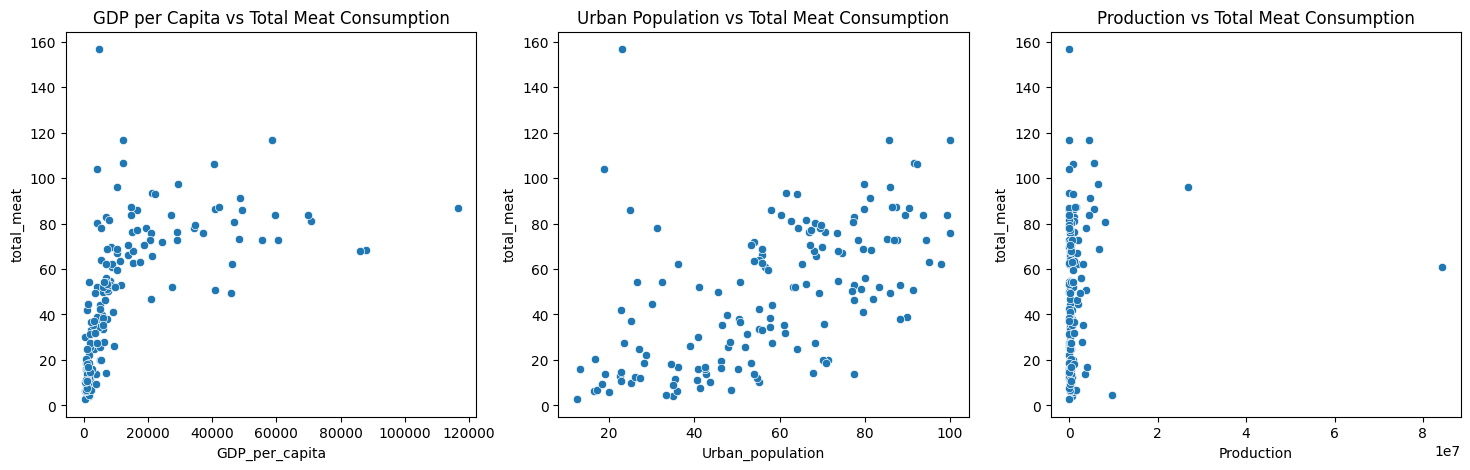

In [42]:
# scatter plots of features vs target
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) 
sns.scatterplot(data=model_df, x="GDP_per_capita", y="total_meat", ax=axes[0])
axes[0].set_title("GDP per Capita vs Total Meat Consumption")
sns.scatterplot(data=model_df, x="Urban_population", y="total_meat", ax=axes[1])
axes[1].set_title("Urban Population vs Total Meat Consumption")
sns.scatterplot(data=model_df, x="Production", y="total_meat", ax=axes[2])
axes[2].set_title("Production vs Total Meat Consumption")       

**<span style="color:#F4E6A1;"><strong>Note</strong></span>** 

Production is a weak predictor of per-capita meat consumption.

## Training 

### Linear|Ridge|Lasso regression

In [80]:
# We will proceed to split the data into training and testing sets,
# standardize the features, and train a few regression models to predict total meat consumption.
X = model_df[feature_cols]
y = model_df["total_meat"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)    
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (123, 3)
Testing set shape: (31, 3)


In [54]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
}

results = []

for model_name, model in models.items():
    if model_name == "Linear Regression":
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    # Evaluate the model
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({
        "Model": model_name,
        "R^2": r2,
        "MSE": mse,
        "MAE": mae
    })

results_df = pd.DataFrame(results)
results_df



,Model,R^2,MSE,MAE
0,Linear Regression,-0.609660,1020.743132,20.282377
1,Ridge Regression,-0.599688,1014.419893,20.265895
2,Lasso Regression,-0.574544,998.474867,20.203638


In [55]:
# Coefficients of the models
for model_name, model in models.items():
    coefs = model.coef_
    coef_df = pd.DataFrame({
        "Feature": feature_cols,
        "Coefficient": coefs
    })
    print(f"\n{model_name} Coefficients:")
    print(coef_df)
    


Linear Regression Coefficients:
            Feature  Coefficient
0    GDP_per_capita     0.000528
1  Urban_population     0.422532
2        Production     0.000002

Ridge Regression Coefficients:
            Feature  Coefficient
0    GDP_per_capita    11.116209
1  Urban_population     9.814907
2        Production     5.074820

Lasso Regression Coefficients:
            Feature  Coefficient
0    GDP_per_capita    11.118678
1  Urban_population     9.805813
2        Production     5.017787


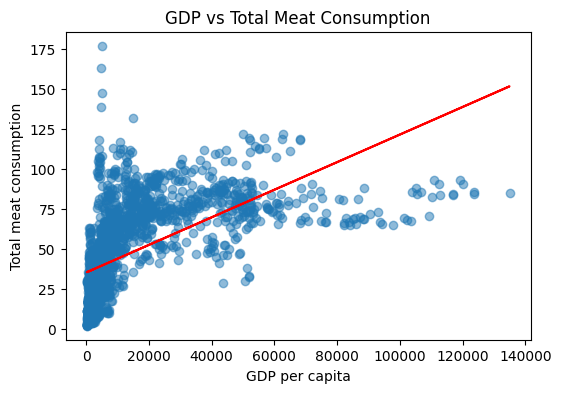

In [71]:
# Training only GDP_per_capita vs total_meat
X = data[['GDP_per_capita']]
y = data['total_meat']

model = Lasso()
model.fit(X, y)

y_pred = model.predict(X)

plt.figure(figsize=(6,4))
plt.scatter(X, y, alpha=0.5, marker='o')
plt.plot(X, y_pred, color='red')
plt.xlabel("GDP per capita")
plt.ylabel("Total meat consumption")
plt.title("GDP vs Total Meat Consumption")
plt.show()


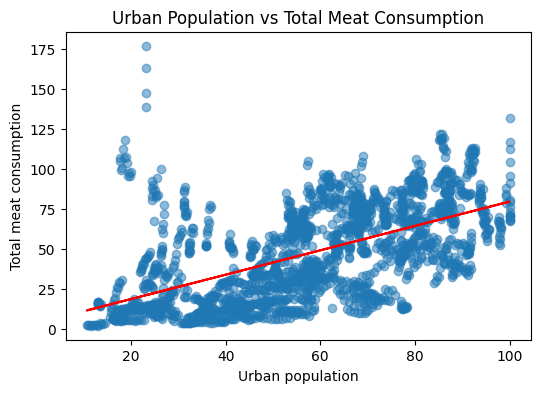

In [70]:
# training only Urban_population vs total_meat
X = data[['Urban_population']]
y = data['total_meat']  
model = Lasso()
model.fit(X, y)
y_pred = model.predict(X)
plt.figure(figsize=(6,4))
plt.scatter(X, y, alpha=0.5)
plt.plot(X, y_pred, color='red')
plt.xlabel("Urban population")
plt.ylabel("Total meat consumption")
plt.title("Urban Population vs Total Meat Consumption")
plt.show()

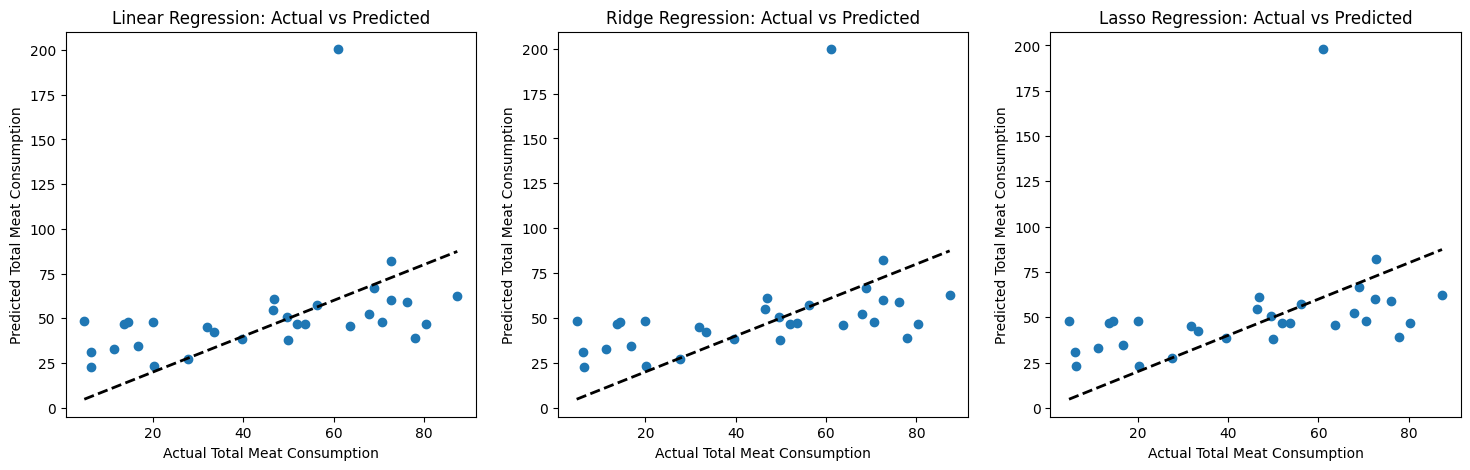

In [63]:
# Plot actual vs predicted for each model, for each feature
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (model_name, model) in enumerate(models.items()):    
    if model_name == "Linear Regression":
        y_pred = model.predict(X_test)
    else:
        y_pred = model.predict(X_test_scaled)
        
    axes[i].scatter(y_test, y_pred)
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    axes[i].set_title(f"{model_name}: Actual vs Predicted")
    axes[i].set_xlabel("Actual Total Meat Consumption")
    axes[i].set_ylabel("Predicted Total Meat Consumption")
       

<span style="color:#F4E6A1;"><strong>Observations</strong></span>

The actual vs. predicted plots show systematic underestimation at high consumption levels and compressed predictions around the mean, indicating underfitting. This behavior arises from non-linear relationships, strong outliers, and limited explanatory power of the selected predictors rather than implementation errors.

**<span style="color:#F4E6A1;"><strong>Modeling note (feature–target relationships)</strong></span>**

Exploratory inspection of individual feature–target relationships reveals that several modeling assumptions required by linear regression are only partially satisfied.

In particular, the relationship between **GDP per capita** and total per-capita meat consumption exhibits a clear non-linear pattern. Consumption increases rapidly at low–to–middle income levels but tends to saturate at higher GDP values, suggesting diminishing returns rather than a globally linear trend. As a result, a single linear fit is unable to capture the full structure of the data and primarily reflects an average trend.

For **urban population (%),** a positive association with meat consumption is observed, although with substantial dispersion and increasing variance at higher urbanization levels. This indicates a weak but consistent linear signal, accompanied by heteroscedasticity and country-level heterogeneity.

In contrast, **meat production** shows negligible correlation with per-capita consumption, consistent with the expectation that production levels do not directly translate into domestic consumption. Based on this observation, production is considered a weak explanatory feature for baseline models.

Overall, these patterns explain the limited predictive performance and visual fit of linear models. The observed behavior highlights the presence of non-linear effects, saturation, and outliers, which cannot be fully captured by simple linear specifications.

This analysis motivates the use of linear models as a **baseline for trend estimation and interpretability**, while acknowledging that more flexible or transformed models would be required to capture the full structure of the data.


### Reescaling target and features: Linear|Ridge|Lasso regresion


<span style="color:#F4E6A1;"><strong>**Modeling note**</strong></span>

Exploratory analysis revealed strong right-skewness and non-linear relationships
between GDP per capita and total meat consumption. To better align the data
with linear model assumptions, logarithmic transformations were applied to both
the target variable (total meat consumption) and GDP per capita prior to training.


In [108]:
# Transforming the space: Total Meat Consumption to log scale using log1p
data['log_total_meat'] = np.log1p(data['total_meat'])
#GDP per capita to log scale using log1p 
data['log_GDP_per_capita'] = np.log1p(data['GDP_per_capita'])
# average log values by country
log_model_df = (
    data.groupby("Country", as_index=False)
        .agg(
            log_total_meat=("log_total_meat", "mean"),
            log_GDP_per_capita=("log_GDP_per_capita", "mean"),
            Urban_population=("Urban_population", "mean"),
            Production=("Production", "mean"),
        )
)

<span style="color:#F4E6A1;"><strong>**Notes**</strong></span>


- Urban population stays the same (for now)
- We exclude production for now: 
    - low correlation, 
    - degenerate distributions, 
    - weird scale and 
    - background noise risk

In [110]:
# Define new modeling dataset with log-transformed variables
features = ['log_GDP_per_capita', 'Urban_population']
target = 'log_total_meat'

X = log_model_df[features]
y = log_model_df[target]    

#spliting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)    

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)       

#defining models with log-transformed target
models_log = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
}

Training set shape: (123, 2)
Testing set shape: (31, 2)


In [111]:
# training and evaluating models with log-transformed target
results_log = []
for model_name, model in models_log.items():
    if model_name == "Linear Regression":
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    # Evaluate the model
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    results_log.append({
        "Model": model_name,
        "R^2": r2,
        "MSE": mse,
        "MAE": mae
    })
results_log_df = pd.DataFrame(results_log)
results_log_df

,Model,R^2,MSE,MAE
0,Linear Regression,0.632274,0.227396,0.366000
1,Ridge Regression,0.631149,0.228092,0.366774
2,Lasso Regression,0.587175,0.255285,0.393177


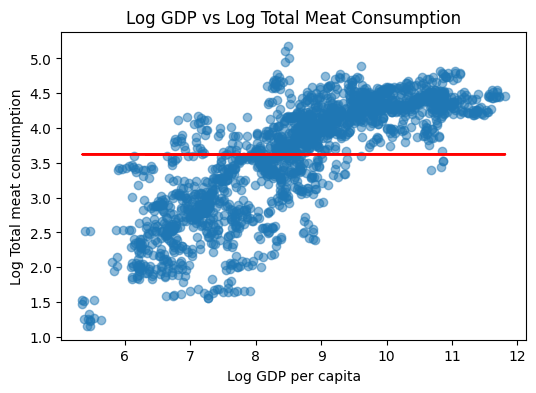

In [112]:
# Training only GDP_per_capita vs total_meat with log transformation and plotting 
X = data[['log_GDP_per_capita']]
y = data['log_total_meat']
model = Lasso()
model.fit(X, y)
y_pred = model.predict(X)   

plt.figure(figsize=(6,4))
plt.scatter(X, y, alpha=0.5, marker='o')
plt.plot(X, y_pred, color='red')
plt.xlabel("Log GDP per capita")
plt.ylabel("Log Total meat consumption")
plt.title("Log GDP vs Log Total Meat Consumption")
plt.show()

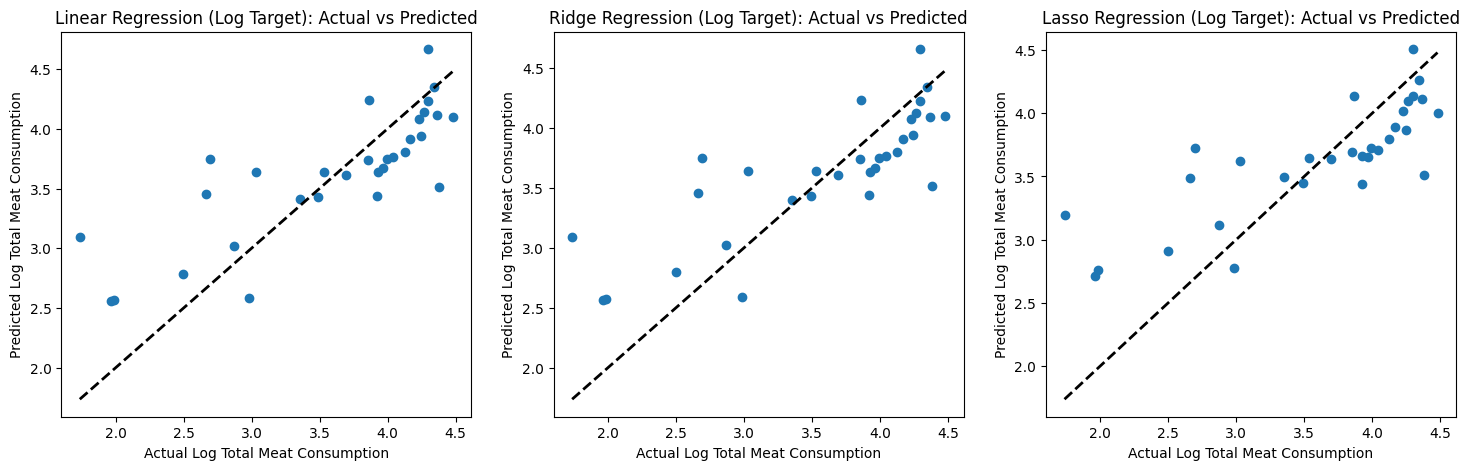

In [113]:
# plot actual vs predicted for log-transformed target
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (model_name, model) in enumerate(models_log.items()):    
    if model_name == "Linear Regression":
        y_pred = model.predict(X_test)
    else:
        y_pred = model.predict(X_test_scaled)
        
    axes[i].scatter(y_test, y_pred)
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    axes[i].set_title(f"{model_name} (Log Target): Actual vs Predicted")
    axes[i].set_xlabel("Actual Log Total Meat Consumption")
    axes[i].set_ylabel("Predicted Log Total Meat Consumption")          
            

<span style="color:#F4E6A1;"><strong>**Notes**</strong></span>

We can observe that transforming the target variable to a logarithmic scale
has improved the model performance, as indicated by higher R^2 values and lower error metrics 
but it is still not ideal. 

<span style="color:#F4E6A1;"><strong>**Observation (Modeling diagnostics)**</strong></span>


Scatter plots between predictors (GDP per capita, urban population) and total meat consumption reveal clear monotonic trends but strong non-linear behavior and heteroscedasticity. 

While log-transformations improve global linear fit and overall predictive performance, substantial variance remains unexplained by linear models. This suggests saturation effects and country-specific heterogeneity that cannot be captured by a single linear relationship.

These observations motivate the exploration of non-linear modeling approaches in the next step.


### Non linear-Models

#### Polynomoal Regression (degree 2)

In [ ]:
# Using the log-transformed model to predict total meat consumption, we will now use polynomial features to see if we can improve the model performance. 
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

In [116]:
# After generating polynomial features, we can proceed to split the data, scale it, and train our models as before. 
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)    
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1541, 2)
Testing set shape: (386, 2)


In [117]:
# Once we split and scaled the polynomial features, we can train our models and evaluate their performance as before.
models_poly = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
}
results_poly = []
for model_name, model in models_poly.items():
    if model_name == "Linear Regression":
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    # Evaluate the model
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    results_poly.append({
        "Model": model_name,
        "R^2": r2,
        "MSE": mse,
        "MAE": mae
    })
results_poly_df = pd.DataFrame(results_poly)
results_poly_df

,Model,R^2,MSE,MAE
0,Linear Regression,0.619969,0.225486,0.336248
1,Ridge Regression,0.618718,0.226228,0.341432
2,Lasso Regression,0.585788,0.245766,0.380769


In [127]:
# Training only GDP_per_capita vs total_meat with polynomial features
X = data[['log_GDP_per_capita']]
y = data['log_total_meat']
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)  


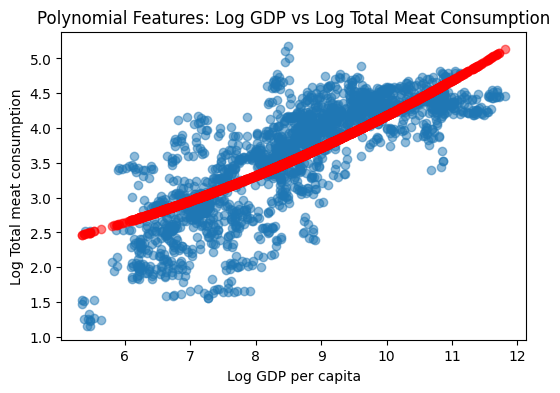

In [128]:
# Plotting polynomial feature model results
model = Lasso()
model.fit(X_poly, y)    
y_pred = model.predict(X_poly)
plt.figure(figsize=(6,4))
plt.scatter(X, y, alpha=0.5, marker='o')
plt.scatter(X, y_pred, color='red', alpha=0.5)
plt.xlabel("Log GDP per capita")
plt.ylabel("Log Total meat consumption")
plt.title("Polynomial Features: Log GDP vs Log Total Meat Consumption")
plt.show()

In [129]:
# Training only urban_population vs total_meat with polynomial features
X = data[['Urban_population']]
y = data['log_total_meat']
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

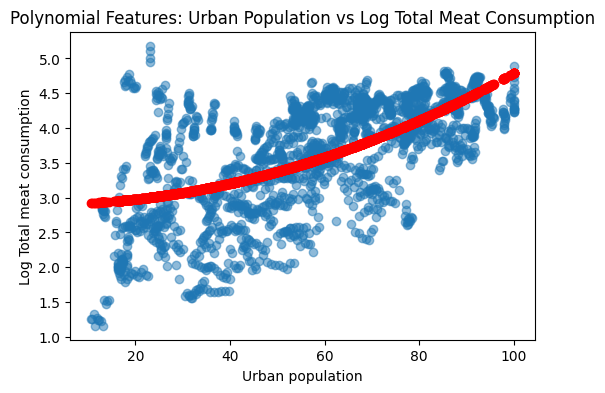

In [140]:
# plotting polynomial feature model results
model = Lasso()
model.fit(X_poly, y)
y_pred = model.predict(X_poly)
plt.figure(figsize=(6,4))
plt.scatter(X, y, alpha=0.5)
plt.scatter(X, y_pred, color='red')
plt.xlabel("Urban population")
plt.ylabel("Log Total meat consumption")
plt.title("Polynomial Features: Urban Population vs Log Total Meat Consumption")
plt.show()  

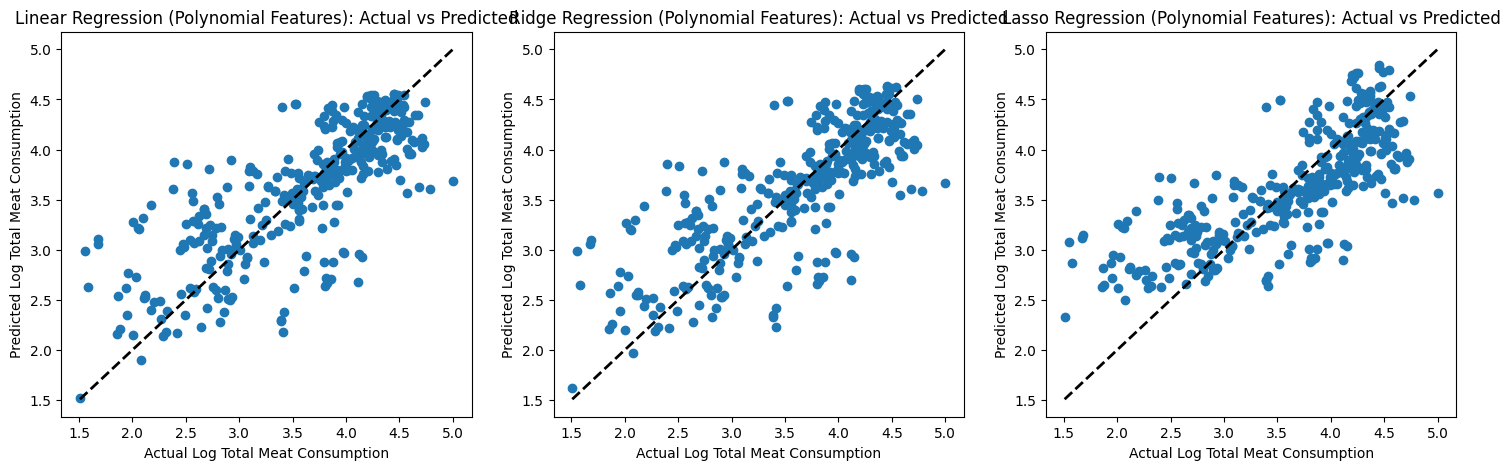

In [131]:
# Now, we can visualize the actual vs predicted values for the polynomial feature models.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (model_name, model) in enumerate(models_poly.items()):    
    if model_name == "Linear Regression":
        y_pred = model.predict(X_test)
    else:
        y_pred = model.predict(X_test_scaled)
        
    axes[i].scatter(y_test, y_pred)
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    axes[i].set_title(f"{model_name} (Polynomial Features): Actual vs Predicted")
    axes[i].set_xlabel("Actual Log Total Meat Consumption")
    axes[i].set_ylabel("Predicted Log Total Meat Consumption")

In [ ]:
# Checkingif there is any imprumovement in model performance with polynomial features 
print("Linear Models Results:\n", results_log_df)
print("\nPolynomial Feature Models Results:\n", results_poly_df)

Linear Models Results:
                Model       R^2       MSE       MAE
0  Linear Regression  0.632274  0.227396  0.366000
1   Ridge Regression  0.631149  0.228092  0.366774
2   Lasso Regression  0.587175  0.255285  0.393177

Polynomial Feature Models Results:
                Model       R^2       MSE       MAE
0  Linear Regression  0.619969  0.225486  0.336248
1   Ridge Regression  0.618718  0.226228  0.341432
2   Lasso Regression  0.585788  0.245766  0.380769


<span style="color:#F4E6A1;"><strong>**Notes**</strong></span>

A simple log-linear model captures most of the explainable variation. More complex functional forms do not yield systematic improvements.

#### Cross-validation of linear and Poly regresion

In [ ]:
# We should do cross-validation to confirm stability of these results.
# we will do  using sklearn's cross_val_score: 

for model_name, model in models_log.items():
    if model_name == "Linear Regression":
        scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    else:
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    print(f"{model_name} Cross-Validation R^2 Scores: {scores}")
    print(f"{model_name} Average R^2 Score: {np.mean(scores)}\n")   


Linear Regression Cross-Validation R^2 Scores: [0.3524761  0.32973152 0.47414588 0.36441427 0.36842031]
Linear Regression Average R^2 Score: 0.3778376157380441

Ridge Regression Cross-Validation R^2 Scores: [0.67381904 0.71455622 0.643393   0.7098764  0.69569821]
Ridge Regression Average R^2 Score: 0.6874685727306632

Lasso Regression Cross-Validation R^2 Scores: [0.64477338 0.64968896 0.60744817 0.65033742 0.65606099]
Lasso Regression Average R^2 Score: 0.6416617857489906



In [144]:
# Crosss validation as well for polynomial feature models
for model_name, model in models_poly.items():
    if model_name == "Linear Regression":
        scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    else:
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    print(f"{model_name} (Polynomial Features) Cross-Validation R^2 Scores: {scores}")
    print(f"{model_name} (Polynomial Features) Average R^2 Score: {np.mean(scores)}\n")
    

Linear Regression (Polynomial Features) Cross-Validation R^2 Scores: [0.3524761  0.32973152 0.47414588 0.36441427 0.36842031]
Linear Regression (Polynomial Features) Average R^2 Score: 0.3778376157380441

Ridge Regression (Polynomial Features) Cross-Validation R^2 Scores: [0.67381904 0.71455622 0.643393   0.7098764  0.69569821]
Ridge Regression (Polynomial Features) Average R^2 Score: 0.6874685727306632

Lasso Regression (Polynomial Features) Cross-Validation R^2 Scores: [0.64477338 0.64968896 0.60744817 0.65033742 0.65606099]
Lasso Regression (Polynomial Features) Average R^2 Score: 0.6416617857489906



In [147]:
# Entrenamos el modelo final
ridge.fit(X_train_scaled, y_train)

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge.coef_
}).sort_values(by="Coefficient", ascending=False)

coefficients


,Feature,Coefficient
0,log_GDP_per_capita,0.596021
1,Urban_population,0.084391


<span style="color:#F4E6A1;"><strong>**Model validation and selection**</strong></span>


Cross-validation confirms that Ridge regression provides the most stable and
accurate performance among the tested models, with an average R² of ~0.69.
Linear regression underfits the data, while Lasso slightly reduces predictive
power by over-penalizing coefficients.

Polynomial feature expansion does not improve performance, indicating that the
log-transformation already captures the relevant non-linear structure.

Coefficient analysis shows that GDP per capita is the dominant driver of meat
consumption, while urban population plays a secondary role.


### Random Fores

In [148]:
# We now train our  model using random forest regressor to see if we can improve performance further.
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [181]:
# We can check if it is worth it to use random forest regressor for this task.
rf = RandomForestRegressor(
    n_estimators=300, 
    max_depth=None,
    min_samples_leaf=5, 
    random_state=42,
    n_jobs=-1
    )
rf.fit(X_train, y_train)

RandomForestRegressor(min_samples_leaf=5, n_estimators=300, n_jobs=-1,
                      random_state=42)

In [182]:
# Predict and evaluate
y_pred = rf.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)   

print('Random Forest Performance:')
print(f'R^2: {r2}')
print(f'MSE: {mse}')
print(f'MAE: {mae}')

Random Forest Performance:
R^2: 0.7093144643343419
MSE: 0.17247388736110142
MAE: 0.2779143404476374


<span style="color:#F4E6A1;"><strong>**Note**</strong></span>

We observe that the random forest regressor outperforms our previous linear models, indicating that it captures non-linear relationships in the data more effectively.

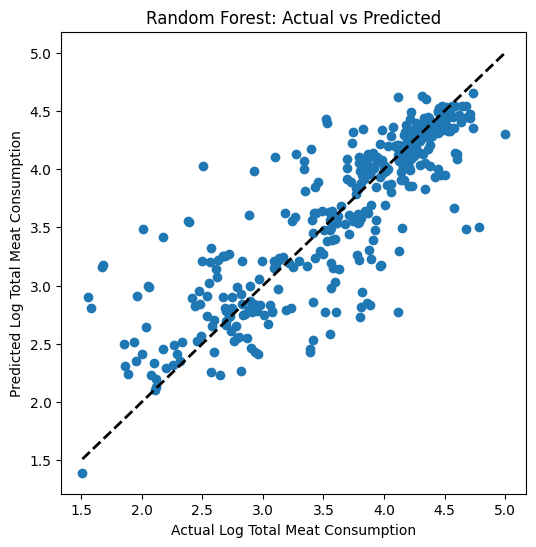

In [183]:
# Plot actual vs predicted for random forest
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual Log Total Meat Consumption")
plt.ylabel("Predicted Log Total Meat Consumption")
plt.show()

In [184]:
# Training only GDP_per_capita vs total_meat with random forest
X_GDP = data[['log_GDP_per_capita']]
y_GDP = data['log_total_meat']
rf = RandomForestRegressor(
    n_estimators=300, 
    max_depth=None,
    min_samples_leaf=5, 
    random_state=42,
    n_jobs=-1
    )
rf.fit(X_GDP, y_GDP)    

RandomForestRegressor(min_samples_leaf=5, n_estimators=300, n_jobs=-1,
                      random_state=42)

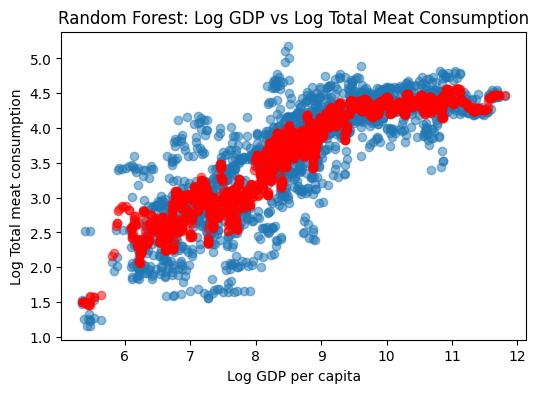

In [185]:
# Plotting actual vs predicted for random forest
y_pred_GDP = rf.predict(X_GDP)
plt.figure(figsize=(6,4))
plt.scatter(X_GDP, y_GDP, alpha=0.5, marker='o')            
plt.scatter(X_GDP, y_pred_GDP, color='red', alpha=0.5)
plt.xlabel("Log GDP per capita")
plt.ylabel("Log Total meat consumption")
plt.title("Random Forest: Log GDP vs Log Total Meat Consumption")
plt.show()

In [186]:
#Traing only urban_population vs total_meat with random forest
X_urb = data[['Urban_population']]
y_urb = data['log_total_meat']
rf = RandomForestRegressor(
    n_estimators=300, 
    max_depth=None,
    min_samples_leaf=5, 
    random_state=42,
    n_jobs=-1
    )
rf.fit(X_urb, y_urb)    


RandomForestRegressor(min_samples_leaf=5, n_estimators=300, n_jobs=-1,
                      random_state=42)

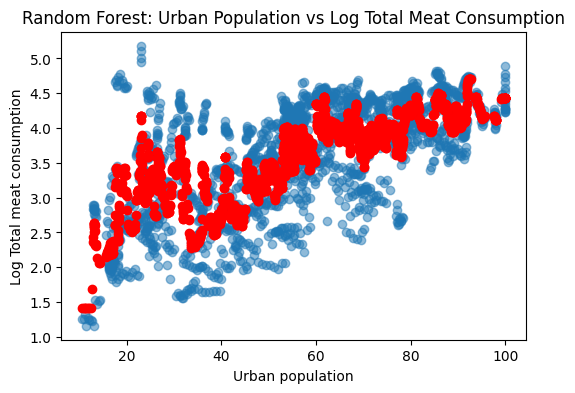

In [187]:
# plotting actual vs predicted for random forest
y_pred_urb = rf.predict(X_urb)
plt.figure(figsize=(6,4))
plt.scatter(X_urb, y_urb, alpha=0.5)
plt.scatter(X_urb, y_pred_urb, color='red')                 
plt.xlabel("Urban population")
plt.ylabel("Log Total meat consumption")
plt.title("Random Forest: Urban Population vs Log Total Meat Consumption")  
plt.show()

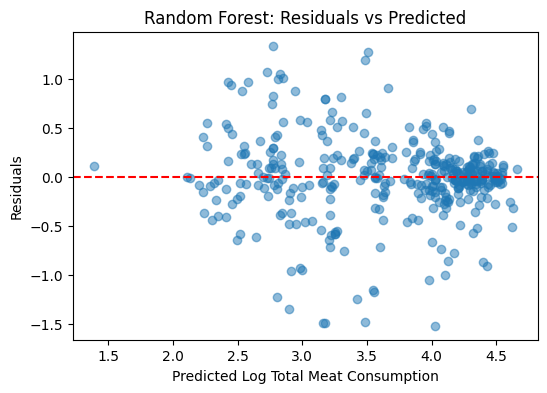

In [188]:
# Residual plot for random forest
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Log Total Meat Consumption")
plt.ylabel("Residuals")
plt.title("Random Forest: Residuals vs Predicted")
plt.show()

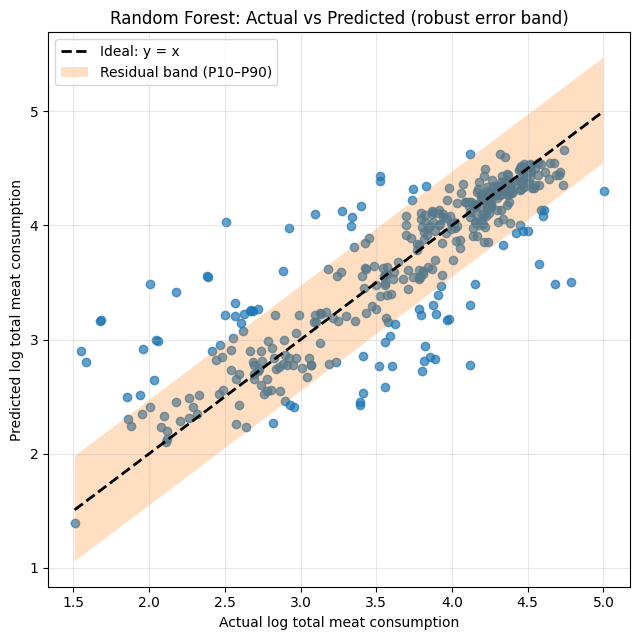

In [189]:


y_true = np.asarray(y_test)
y_hat  = np.asarray(y_pred)

residuals = y_hat - y_true

# Percentile-based band (e.g., 10th–90th or 25th–75th)
low_q, high_q = np.percentile(residuals, [10, 90])

x_line = np.linspace(y_true.min(), y_true.max(), 200)

plt.figure(figsize=(6.5, 6.5))
plt.scatter(y_true, y_hat, alpha=0.7)

plt.plot(x_line, x_line, 'k--', lw=2, label='Ideal: y = x')

# Band around ideal line using residual quantiles
plt.fill_between(x_line, x_line + low_q, x_line + high_q, alpha=0.25,
                 label=f"Residual band (P10–P90)")

plt.title("Random Forest: Actual vs Predicted (robust error band)")
plt.xlabel("Actual log total meat consumption")
plt.ylabel("Predicted log total meat consumption")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()




<span style="color:#F4E6A1;"><strong>**Summary (Model evaluation)**</strong></span>

The Random Forest model captures the nonlinear relationship between socio-economic features and per-capita meat consumption.
Predictions align closely with the ideal y = x relationship, with most observations falling within a robust error band (P10–P90), indicating stable predictive performance across the target range.


<span style="color:#F4E6A1;"><strong>**Residual diagnostics**</strong></span>


Residuals are centered around zero with no strong systematic patterns, suggesting that remaining errors are largely stochastic rather than driven by unmodeled structure.